# Proyek Machine Learning Pemula: Beverage Sales Dataset 
- **Nama:** Audy Nadira Ramadanti
- **Email:** audynadiraramdanti@gmail.com
- **ID Dicoding:** audy_nadira_ramadanti_zWZ9

# **1. Import Library**

In [14]:
#Type your code here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier


Sebelum memulai pemrosesan data, saya memerlukan beberapa library yang membantu dalam pengolahan, analisis, dan visualisasi data, serta penerapan algoritma clustering. Berikut adalah penjelasan singkat mengenai masing-masing library dan fungsi yang diimpor:

**1. `pandas` (`import pandas as pd`)**  
   - Digunakan untuk **manipulasi dan analisis data**.  
   - Memiliki struktur data **DataFrame** dan **Series** yang memudahkan operasi seperti membaca, menulis, menggabungkan, dan memfilter data.

**2. `NumPy` (`import numpy as np`)**  
   - Menyediakan **array multidimensi** yang efisien dan berbagai fungsi matematika untuk perhitungan numerik.  
   - Sering digunakan bersama Pandas untuk melakukan operasi numerik yang lebih kompleks.

**3. `matplotlib.pyplot` (`import matplotlib.pyplot as plt`)**  
   - Memungkinkan pembuatan **grafik dan visualisasi data** dasar, seperti plot garis, histogram, dan scatter plot.  
   - Sangat fleksibel dan dapat dikustomisasi untuk berbagai jenis visualisasi.

**4. `seaborn` (`import seaborn as sns`)**  
   - Memperluas Matplotlib dengan **tampilan visualisasi statistik** yang lebih menarik dan mudah dipahami.  
   - Memiliki fungsi bawaan untuk membuat plot seperti heatmap, boxplot, dan pairplot secara lebih sederhana.

**5. `OneHotEncoder` (`from sklearn.preprocessing import OneHotEncoder`)**  
   - Digunakan untuk **mengubah (encode) fitur kategorikal** menjadi variabel dummy (kolom biner).  
   - Sangat berguna ketika fitur kategorikal tidak bersifat ordinal dan memiliki beberapa kategori unik.

**6. `LabelEncoder` (`from sklearn.preprocessing import LabelEncoder`)**  
   - Mengubah nilai kategori menjadi **label numerik** (misalnya 0, 1, 2, dst.).  
   - Cocok untuk kasus di mana kolom kategorikal bisa diwakili oleh integer label tanpa perlu menambah banyak kolom baru.

**7. `MinMaxScaler` (`from sklearn.preprocessing import MinMaxScaler`)**  
   - Digunakan untuk **menormalisasi** atau **menskalakan** data numerik ke dalam rentang tertentu, biasanya [0, 1].  
   - Membantu algoritma *machine learning* yang sensitif terhadap skala data agar kinerjanya lebih optimal.

**8. `train_test_split` (`from sklearn.model_selection import train_test_split`)**  
   - Memudahkan **pembagian dataset** menjadi **data latih** dan **data uji** secara acak.  
   - Membantu dalam memvalidasi model dengan mengecek performa pada data yang belum pernah dilihat sebelumnya.

**9. `classification_report` (`from sklearn.metrics import classification_report`)**  
   - Memberikan **ringkasan metrik evaluasi** untuk tugas klasifikasi, seperti **precision**, **recall**, dan **f1-score**.  
   - Memudahkan kita untuk melihat performa model di setiap kelas secara rinci.

**10. `accuracy_score` (`from sklearn.metrics import accuracy_score`)**  
   - Menghitung **akurasi** model klasifikasi, yaitu persentase prediksi benar dari keseluruhan data uji.  
   - Salah satu metrik umum untuk menilai performa model klasifikasi.

**11. `LogisticRegression` (`from sklearn.linear_model import LogisticRegression`)**  
   - Model klasifikasi yang menggunakan **regresi logistik** untuk memprediksi kelas (0/1).  
   - Sering digunakan sebagai baseline karena sederhana namun cukup efektif.

**12. `RandomForestClassifier` (`from sklearn.ensemble import RandomForestClassifier`)**  
   - Model **ensemble** berbasis banyak *decision tree* yang dikombinasikan secara acak (random) untuk meningkatkan akurasi dan mengurangi *overfitting*.

**13. `xgboost` (`import xgboost as xgb`)**  
   - Model **gradient boosting** yang efisien dan seringkali memberikan performa tinggi dalam berbagai kompetisi data.  
   - Mampu menangani data dengan jumlah fitur besar dan mendukung *regularization* yang baik.

**14. `GridSearchCV` (`from sklearn.model_selection import GridSearchCV`)**  
   - Melakukan **pencarian sistematis** atas kombinasi parameter yang ditentukan untuk menemukan **hyperparameter** optimal.  
   - Menggunakan teknik **cross-validation** dalam proses pencariannya.

**15. `RandomizedSearchCV` (`from sklearn.model_selection import RandomizedSearchCV`)**  
   - Alternatif yang lebih **efisien** daripada GridSearchCV dengan melakukan **pencarian acak** pada ruang parameter.  
   - Cocok untuk ruang parameter yang besar atau waktu komputasi yang terbatas.

**16. `learning_curve` (`from sklearn.model_selection import learning_curve`)**  
   - Digunakan untuk **membuat kurva pembelajaran** yang menunjukkan bagaimana kinerja model berubah dengan bertambahnya data latih.  
   - Membantu mendeteksi apakah model mengalami *overfitting* atau *underfitting*.

**17. `cross_val_score` (`from sklearn.model_selection import cross_val_score`)**  
   - Memungkinkan kita melakukan **evaluasi model** dengan *k-fold cross-validation* secara mudah.  
   - Menghasilkan skor performa di setiap fold, sehingga kita bisa melihat **variabilitas** dan **rata-rata** performa model.

**18. `MLPClassifier` (`from sklearn.neural_network import MLPClassifier`)**  
   - Model **Neural Network** (Multi-Layer Perceptron) dari scikit-learn.  
   - Mampu mempelajari hubungan non-linear dalam data melalui beberapa lapisan tersembunyi.

# **2. Memuat Dataset dari Hasil Clustering**

In [15]:
#Type your code here

data = pd.read_csv("data/Data_Clustering.csv")

Karena sebelumnya kita sudah mendapatkan **label** dari pemodelan klasterisasi dan telah menyimpannya dalam file **CSV** (`Data_Clustering.csv`), selanjutnya saya akan **menggunakannya untuk proses klasifikasi**. Hal ini saya lakukan dengan **menjadikan kolom hasil klasterisasi sebagai target (label)** dalam pendekatan **supervised learning**. Dengan demikian, kita dapat membangun model klasifikasi (misalnya Decision Tree, Random Forest, atau Logistic Regression) yang mampu memprediksi **segmen pelanggan** (label klaster) untuk data baru berdasarkan fitur-fitur yang tersedia.

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer_ID    10000 non-null  object 
 1   Order_ID       10000 non-null  object 
 2   Unit_Price     10000 non-null  float64
 3   Total_Price    10000 non-null  float64
 4   Quantity       10000 non-null  float64
 5   Discount       10000 non-null  float64
 6   Region         10000 non-null  object 
 7   Cluster        10000 non-null  int64  
 8   Customer_Type  10000 non-null  object 
dtypes: float64(4), int64(1), object(4)
memory usage: 703.3+ KB


Sebelum mulai memproses data, langkah pertama yang saya lakukan adalah **memeriksa struktur dataset** dengan menggunakan `data.info()`. Dari hasil tersebut, dapat dilihat:

- **Jumlah baris**: 10.000  
- **Jumlah kolom**: 10  
- **Tipe data**:  
  - 5 kolom bertipe *object* (`Customer_ID`, `Order_ID`, `Region`, `Customer_Type`, `Customer_Segment`)  
  - 4 kolom bertipe *float64* (`Unit_Price`, `Total_Price`, `Quantity`, `Discount`)  
  - 1 kolom bertipe *int64* (`Cluster`)  
- **Tidak ada missing values** (semua kolom memiliki 10.000 non-null entries).  
- **Penggunaan memori**: sekitar 781.4 KB.

Dengan mengetahui struktur data seperti ini, kita bisa merencanakan **langkah preprocessing** selanjutnya, misalnya:
- Mengecek apakah kolom bertipe *object* perlu diubah ke tipe kategori atau tipe numerik tertentu.  
- Melakukan *feature engineering* jika diperlukan (contoh: menghitung metrik baru dari `Unit_Price` dan `Quantity`, atau menganalisis segmen pelanggan berdasarkan `Customer_Type`).  
- Menentukan metode yang tepat untuk menangani data jika ada anomali (misalnya nilai ekstrem pada `Discount` atau `Total_Price`).  

Langkah awal ini penting agar kita memahami karakteristik dasar dataset sebelum melakukan analisis lebih lanjut.

# **3. Pre-Processing Data**

In [17]:
#Type your code here

data = data.drop(columns=["Customer_ID", "Order_ID"])

Karena menurut saya kolom **`Customer_ID`** dan **`Order_ID`** tidak memberikan informasi yang relevan untuk keperluan pemodelan klasifikasi (umumnya hanya bersifat *identifier* yang unik untuk setiap entitas), saya memutuskan untuk menghapusnya. Proses penghapusan ini dilakukan dengan:

```python
data = data.drop(columns=["Customer_ID", "Order_ID"])
```

Tujuannya adalah untuk menyederhanakan dataset sehingga hanya kolom yang berpotensi memberikan *insight* prediktif yang tersisa. Langkah ini juga membantu **mencegah kebocoran data** (data leakage) serta mengurangi kebisingan (*noise*) yang dapat mempengaruhi kinerja model.

In [18]:
le = LabelEncoder()
data['Region'] = le.fit_transform(data['Region'])

Selanjutnya, saya melakukan **encoding** pada data bersifat kategorikal, khususnya pada fitur **`Region`**. Karena fitur ini memiliki nilai unik yang sangat banyak, saya menggunakan **`LabelEncoder`** agar setiap kategori dapat diubah menjadi representasi numerik. Dengan demikian, model *machine learning* yang umumnya hanya menerima input numerik akan lebih mudah mengolah variabel **`Region`** tanpa kehilangan informasi kategorikalnya.

In [19]:
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' untuk menghindari multikolinearitas
encoded_region = encoder.fit_transform(data[['Customer_Type']])

region_df = pd.DataFrame(encoded_region, columns=encoder.get_feature_names_out(['Customer_Type']))

data = data.drop(columns=['Customer_Type']).reset_index(drop=True)
data = pd.concat([data, region_df], axis=1)


Selanjutnya, saya menerapkan **One Hot Encoding** pada fitur **`Customer_Type`**. Meskipun fitur ini hanya memiliki 2 kategori unik, proses ini tetap diperlukan agar setiap kategori dapat diwakili oleh nilai biner (0 atau 1) yang mudah dipahami oleh model. Selain itu, saya menggunakan parameter **`drop='first'`** untuk menghindari masalah *multicollinearity* atau *dummy variable trap*, di mana salah satu kolom akan menjadi *baseline* dan tidak perlu ditampilkan secara eksplisit. 

Dengan demikian, setelah proses ini, dataset akan memiliki kolom baru yang mewakili kategori **`Customer_Type`** secara numerik, sementara kolom aslinya sudah dihapus agar tidak menimbulkan redundansi.

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unit_Price         10000 non-null  float64
 1   Total_Price        10000 non-null  float64
 2   Quantity           10000 non-null  float64
 3   Discount           10000 non-null  float64
 4   Region             10000 non-null  int32  
 5   Cluster            10000 non-null  int64  
 6   Customer_Type_B2C  10000 non-null  float64
dtypes: float64(5), int32(1), int64(1)
memory usage: 507.9 KB


Setelah proses *encoding*, saya kembali memeriksa struktur data menggunakan `data.info()`. Hasilnya menunjukkan bahwa:

- Kolom **`Region`** kini sudah bertipe numerik (`int32`) berkat proses *label encoding*.  
- Kolom **`Customer_Type_B2C`** juga telah ditambahkan sebagai kolom baru dengan tipe *float64*, menandakan bahwa *one-hot encoding* berhasil dilakukan.  
- Kolom **`Customer_Segment`** masih bertipe *object*, sehingga jika dibutuhkan, kita bisa melakukan proses encoding lebih lanjut di kolom tersebut.

Dengan demikian, data yang bersifat kategorikal telah berubah menjadi numerik sesuai yang diharapkan, dan kita siap melanjutkan proses *preprocessing* atau analisis/pemodelan selanjutnya.

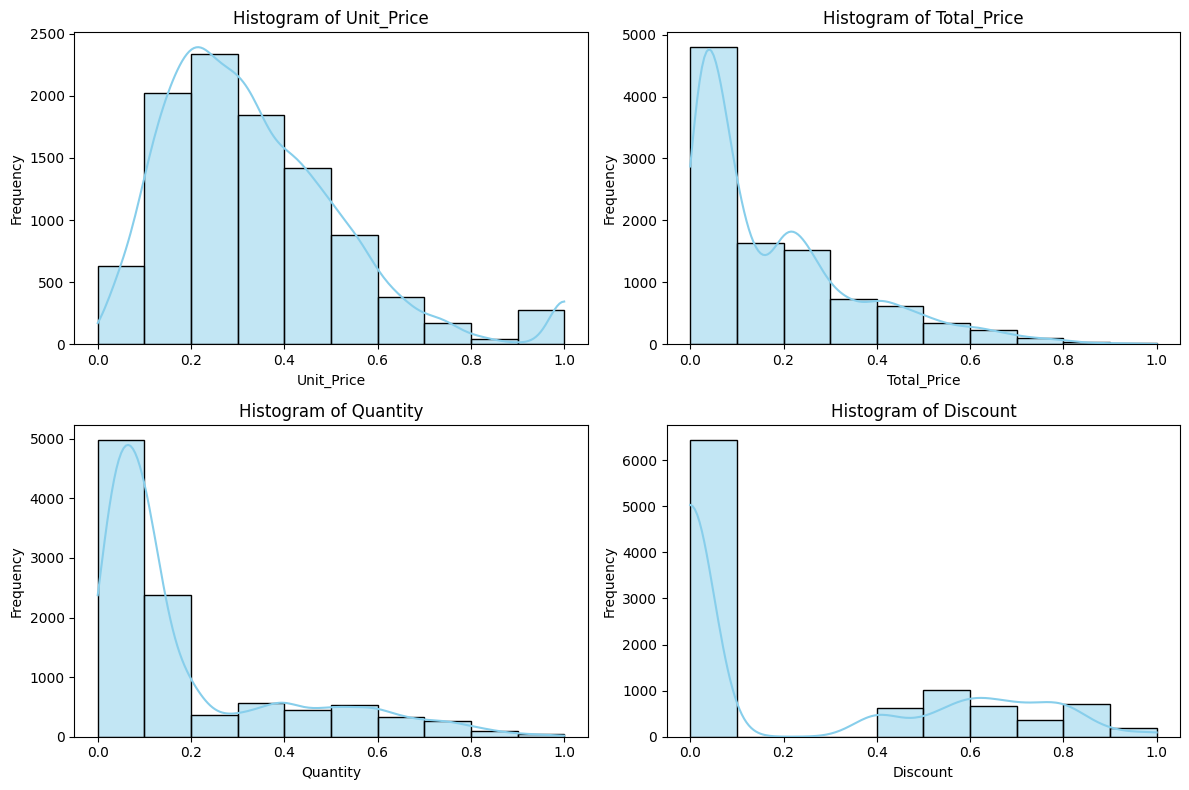

In [21]:
scaler = MinMaxScaler()
columns_to_normalize = ['Unit_Price', 'Total_Price', 'Quantity', 'Discount']
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])

# Plot histogram
plt.figure(figsize=(12, 8))
for i, col in enumerate(columns_to_normalize, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[col], bins=10, kde=True, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Terakhir, sebelum memasuki tahap pemodelan, saya melakukan **normalisasi data** menggunakan **`MinMaxScaler`** pada kolom-kolom numerik, yaitu **`Unit_Price`, `Total_Price`, `Quantity`, dan `Discount`**. Tujuan normalisasi ini adalah untuk **menskalakan** setiap fitur numerik ke rentang [0, 1], sehingga:

1. **Rentang nilai** menjadi seragam dan tidak ada fitur yang memiliki skala jauh lebih besar dibandingkan fitur lainnya.  
2. **Algoritma pemodelan**—terutama yang sensitif terhadap skala data (misalnya *k-Nearest Neighbors* atau *Neural Networks*)—dapat bekerja lebih optimal.  

Setelah normalisasi, saya juga **memvisualisasikan histogram** untuk memeriksa distribusi data hasil normalisasi. Dengan demikian, kita bisa memastikan bahwa proses normalisasi berjalan sesuai harapan dan siap melanjutkan ke tahap pemodelan.

# **4. Data Splitting**

In [22]:
#Type your code here

X = data.drop(columns=["Cluster"])  # Fitur
y = data["Cluster"]  # Target

Sebelum memasuki tahap pemodelan, saya memisahkan dataset menjadi **fitur (X)** dan **target (y)**. Dalam kode ini, kolom **`Cluster`** digunakan sebagai target yang akan diprediksi (**y**), sementara **X** berisi semua kolom lainnya setelah menghapus **`Cluster`**. Dengan demikian, **X** hanya terdiri dari fitur yang akan digunakan untuk pelatihan model, sedangkan **y** menyimpan label kategori untuk setiap data. Tidak diperlukan proses *encoding* karena **`Cluster`** sudah berbentuk numerik dan dapat langsung digunakan dalam model *machine learning*.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y , random_state=42, test_size=0.3, shuffle=True) 

Saya membagi data menjadi **data latih (X_train, y_train)** dan **data uji (X_test, y_test)** dengan proporsi 70% data latih dan 30% data uji (ditentukan oleh `test_size=0.3`). Saya juga menggunakan parameter `shuffle=True` untuk mengacak urutan data sebelum pembagian, serta `random_state=42` agar proses pembagian ini **reproducible**—sehingga jika kode dijalankan kembali, hasil pembagian akan sama.  

# **5. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [24]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


# 2. Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


# 3. Multi Layer Perceptron
mlp_model = MLPClassifier(random_state=42, max_iter=1000)  
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)


c:\Users\FX506\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Masuk ke dalam tahap pemodelan klasifikasi disini saya menggunakan **tiga algoritma klasifikasi** untuk memprediksi **Customer_Segment**:

1. **Logistic Regression**  
   - Menggunakan **regresi logistik** dengan parameter `max_iter=1000` dan `random_state=42`.  
   - Setelah proses pelatihan dengan data latih (`X_train`, `y_train`), saya menghasilkan prediksi (`y_pred_lr`) pada data uji (`X_test`).

2. **Random Forest Classifier**  
   - Model **ensemble** yang terdiri dari banyak *decision tree* dengan `n_estimators=100` dan `random_state=42`.  
   - Dilatih pada data latih, kemudian digunakan untuk memprediksi data uji (`y_pred_rf`).

3. **Multi Layer Perceptron (MLP)**  
   - **Neural Network** sederhana dengan parameter `max_iter=1000` dan `random_state=42`.  
   - Dilatih dengan data latih, dan prediksi dihasilkan untuk data uji (`y_pred_mlp`).

Dengan menggunakan ketiga model ini, saya dapat membandingkan kinerja dan memilih model yang paling baik dalam memprediksi **Customer_Segment**.

## **b. Evaluasi Model Klasifikasi**

In [25]:
#Type your code here

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("\n")

print("Random Forest Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("\n")

print("MLP Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

Logistic Regression
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       208
           1       1.00      1.00      1.00       356
           2       1.00      1.00      1.00       369
           3       1.00      1.00      1.00       178
           4       1.00      1.00      1.00       355
           5       1.00      1.00      1.00       378
           6       1.00      1.00      1.00       188
           7       1.00      1.00      1.00       369
           8       1.00      1.00      1.00       398
           9       1.00      1.00      1.00       201

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



Random Forest Classifier
Accuracy: 0.9966666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       208
           1       1.00      1.00      1.0

1. **Logistic Regression**  
   - Mencapai **akurasi sempurna (1.0)**, dengan **precision**, **recall**, dan **f1-score** **1.00** pada semua kelas.  
   - Hasil ini menunjukkan bahwa model dapat memisahkan setiap kelas dengan sangat baik. Namun, akurasi sempurna juga bisa mengindikasikan bahwa dataset **terlalu mudah** atau terdapat **data leakage** (fitur yang terlalu informatif), sehingga perlu diuji kembali dengan data lain atau metode validasi yang lebih ketat.

2. **Random Forest Classifier**  
   - Mencapai **akurasi yang hampir sempurna (99.67%)**, dengan precision, recall, dan f1-score yang **mendekati 1.00** di seluruh kelas.  
   - Meskipun sedikit di bawah Logistic Regression dan MLP, performa ini tetap **sangat tinggi**. Perlu diperhatikan bahwa hasil yang sangat tinggi ini harus diuji di data baru atau dilakukan **repeated cross-validation** untuk memastikan model tidak **overfitting**.

3. **MLP Classifier**  
   - Mencapai **akurasi sempurna (1.0)**, sama seperti Logistic Regression, dengan precision, recall, dan f1-score **1.00** di semua kelas.  
   - Kinerja sempurna ini menunjukkan MLP berhasil mempelajari pola data secara menyeluruh. Sama seperti kasus Logistic Regression, perlu **verifikasi lebih lanjut** untuk memastikan tidak terjadi overfitting atau data leakage.


### Kesimpulan Umum
- **Ketiga model** (Logistic Regression, Random Forest, dan MLP) menunjukkan **kinerja yang sangat tinggi** pada dataset ini, dengan Logistic Regression dan MLP sama-sama mencapai akurasi sempurna (1.0), sementara Random Forest sedikit di bawahnya tetapi tetap hampir sempurna.  
- **Kemungkinan penyebab** kinerja yang terlalu tinggi mencakup:  
  1. **Dataset terlalu mudah** atau **terlalu sedikit** sehingga model “menghafal” pola dengan mudah,  
  2. **Data leakage** atau fitur yang sangat informatif,  
  3. Perlu **validasi tambahan** (misalnya, data baru, repeated cross-validation, atau peningkatan kompleksitas data) untuk memastikan model benar-benar dapat **menggeneralisasi** di luar data latih.

## **c. Tuning Model Klasifikasi (Optional)**

In [26]:
#Type your code here

# 1. Logistic Regression dengan GridSearchCV
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],  # untuk l1 gunakan solver liblinear
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                         param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train, y_train)


# 2. Random Forest Classifier dengan RandomizedSearchCV
param_dist_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rand_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                             param_distributions=param_dist_rf,
                             n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
rand_rf.fit(X_train, y_train)



from sklearn.model_selection import GridSearchCV

# Contoh parameter grid
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (50, 50), (100,)],   # Contoh variasi layer
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate': ['constant', 'adaptive']
}

mlp_grid = GridSearchCV(
    MLPClassifier(random_state=42, max_iter=1000),
    param_grid_mlp,
    cv=5,              
    scoring='accuracy',
    n_jobs=-1          
)

mlp_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=MLPClassifier(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'hidden_layer_sizes': [(50,), (50, 50), (100,)],
                         'learning_rate': ['constant', 'adaptive'],
                         'solver': ['adam', 'sgd']},
             scoring='accuracy')

Selanjutnya, saya kembali menerapkan **tiga algoritma** tersebut (**Logistic Regression**, **Random Forest**, dan **MLP**) namun dengan **strategi hyperparameter tuning**. Tujuannya adalah untuk mencari kombinasi parameter yang **optimal**, sehingga kinerja model dapat meningkat. Berikut pendekatan yang dilakukan:

1. **Logistic Regression (GridSearchCV)**  
   - Saya menggunakan **GridSearchCV** dengan beberapa variasi parameter seperti `C`, `penalty`, dan `solver`.  
   - **GridSearchCV** akan mencoba semua kombinasi parameter dalam `param_grid_lr` menggunakan *k-fold cross-validation*, lalu memilih kombinasi dengan **akurasi** terbaik.

2. **Random Forest Classifier (RandomizedSearchCV)**  
   - Untuk **Random Forest**, saya memanfaatkan **RandomizedSearchCV**, di mana parameter seperti `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, dan `bootstrap` di-*sampling* secara acak dari daftar yang ditentukan.  
   - **RandomizedSearchCV** lebih efisien daripada GridSearchCV ketika ruang parameter cukup besar, karena tidak mencoba semua kombinasi melainkan **hanya sejumlah iterasi** (ditentukan oleh `n_iter`).

3. **MLPClassifier (GridSearchCV)**  
   - Untuk **MLP**, saya kembali menggunakan **GridSearchCV** dengan variasi parameter `hidden_layer_sizes`, `activation`, `solver`, dan `learning_rate`.  
   - Prosesnya serupa dengan Logistic Regression, yaitu memeriksa semua kombinasi parameter lalu memilih yang terbaik berdasarkan **akurasi**.

Dengan cara ini, setiap model berpeluang menunjukkan performa maksimal setelah melalui pencarian parameter terbaik, dibandingkan dengan penggunaan parameter default.

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

In [27]:
#Type your code here

print("Best parameters for Logistic Regression:", grid_lr.best_params_)
y_pred_lr = grid_lr.predict(X_test)
print("Logistic Regression Accuracy After Tuning:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("\n")



print("Best parameters for Random Forest:", rand_rf.best_params_)
y_pred_rf = rand_rf.predict(X_test)
print("Random Forest Accuracy After Tuning:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("\n")


print("Best parameters for MLP:", mlp_grid.best_params_)
y_pred_mlp_tuned = mlp_grid.predict(X_test)
print("MLP Accuracy After Tuning:", accuracy_score(y_test, y_pred_mlp_tuned))
print(classification_report(y_test, y_pred_mlp_tuned))


Best parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Logistic Regression Accuracy After Tuning: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       208
           1       1.00      1.00      1.00       356
           2       1.00      1.00      1.00       369
           3       1.00      1.00      1.00       178
           4       1.00      1.00      1.00       355
           5       1.00      1.00      1.00       378
           6       1.00      1.00      1.00       188
           7       1.00      1.00      1.00       369
           8       1.00      1.00      1.00       398
           9       1.00      1.00      1.00       201

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



Best parameters for Random Forest: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 2, '

1. **Logistic Regression**  
   - **Best Parameters**: `{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}`  
   - **Akurasi Setelah Tuning**: **1.0**  
   - Seluruh metrik (precision, recall, f1-score) untuk setiap kelas menunjukkan nilai **1.00**, menandakan model berhasil memprediksi seluruh data uji dengan tepat.  
   - Meskipun hasil ini terlihat **sempurna**, perlu dicermati apakah dataset terlalu mudah atau terjadi **data leakage**. Diperlukan **validasi tambahan** (misalnya uji pada data baru) untuk memastikan model benar-benar dapat **menggeneralisasi**.

2. **Random Forest**  
   - **Best Parameters**: `{'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': True}`  
   - **Akurasi Setelah Tuning**: **0.9986667 (sekitar 99.87%)**  
   - Model ini menunjukkan performa yang **hampir sempurna** di semua metrik, hanya terpaut sedikit dari skor 1.0.  
   - Seperti halnya Logistic Regression, akurasi yang sangat tinggi ini perlu diuji kembali pada **data berbeda** atau dengan **metode validasi** yang lebih ketat untuk menghindari **overfitting**.

3. **MLPClassifier**  
   - **Best Parameters**: `{'activation': 'relu', 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'solver': 'adam'}`  
   - **Akurasi Setelah Tuning**: **1.0**  
   - Sama seperti Logistic Regression, MLP meraih nilai **sempurna** pada seluruh metrik evaluasi.  
   - Hasil ini juga **perlu diverifikasi lebih lanjut** karena kinerja 100% di dunia nyata biasanya menandakan bahwa data **sangat mudah diprediksi** atau terdapat **faktor lain** (misalnya data leakage).


### Kesimpulan Umum
- **Ketiga model** mencapai performa **sangat tinggi** (bahkan sempurna untuk Logistic Regression dan MLP) setelah tuning.  
- **Akurasi yang mendekati atau sama dengan 1.0** harus dikaji dengan hati-hati, karena bisa mengindikasikan **dataset yang terlalu mudah**, **overfitting**, atau **data leakage**.  
- **Disarankan** untuk melakukan uji coba tambahan, seperti:
  - Menggunakan **dataset uji terpisah** atau **data baru** untuk melihat performa di luar data latih.  
  - Menerapkan **repeated cross-validation** untuk memastikan hasil tidak kebetulan.  
  - Menambah **kompleksitas** atau **variasi** pada dataset guna menguji daya generalisasi model.

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

## 1. Apakah Hasil Setelah Tuning Lebih Baik

Berdasarkan **dua penjelasan** (sebelum dan sesudah tuning) yang Anda berikan:

- **Logistic Regression**  
  - **Sebelum Tuning**: Akurasi **1.0**  
  - **Sesudah Tuning**: Akurasi **1.0**  
  - **Kesimpulan**: Tidak ada peningkatan karena sejak awal sudah mencapai skor sempurna.  

- **Random Forest**  
  - **Sebelum Tuning**: Akurasi **99.67%**  
  - **Sesudah Tuning**: Akurasi **99.87%**  
  - **Kesimpulan**: Terdapat sedikit peningkatan dari 99.67% ke 99.87%, meskipun keduanya sudah tergolong sangat tinggi.  

- **MLP Classifier**  
  - **Sebelum Tuning**: Akurasi **1.0**  
  - **Sesudah Tuning**: Akurasi **1.0**  
  - **Kesimpulan**: Sama seperti Logistic Regression, tidak ada peningkatan karena model sudah mencapai skor sempurna sebelum tuning.  

**Jawaban untuk Pertanyaan “Apakah Hasil Setelah Tuning Lebih Baik?”**  
- Secara keseluruhan, **Random Forest** memang mengalami sedikit peningkatan akurasi setelah tuning.  
- **Logistic Regression** dan **MLP** sudah sempurna sejak sebelum tuning, sehingga **tidak terlihat peningkatan** lebih lanjut (tetap 1.0).  

Namun, akurasi sempurna atau hampir sempurna tersebut **perlu diuji lebih lanjut** untuk memastikan tidak ada masalah seperti **data terlalu mudah**, **data leakage**, atau **overfitting**.

## 2. Berdasarkan Akurasi yang di Dapatkan Apakah Model mengalami Overfitting

c:\Users\FX506\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\FX506\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Cross-Validation Accuracy Scores: [1. 1. 1. 1. 1.]
Rata-rata CV Accuracy: 1.0


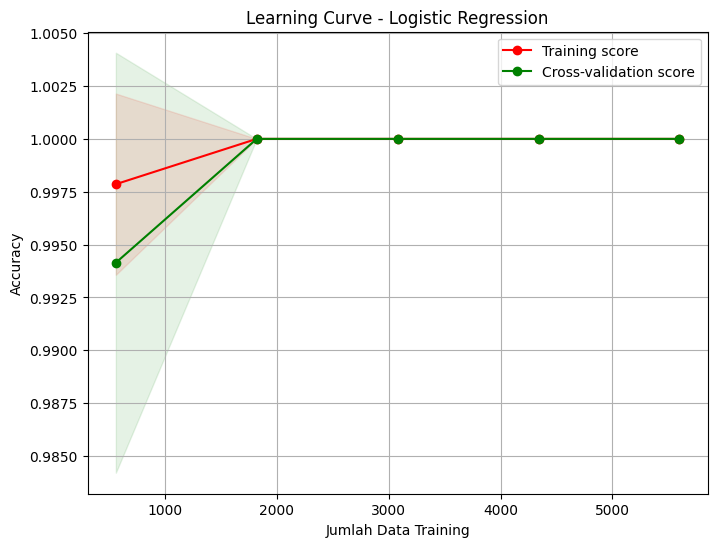

In [31]:
# 1. Cross Validation
# Menggunakan 5-fold cross-validation pada Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
cv_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Accuracy Scores:", cv_scores)
print("Rata-rata CV Accuracy:", np.mean(cv_scores))

# 2. Learning Curve
# Menggunakan learning_curve untuk mendapatkan performa model pada berbagai ukuran data training
train_sizes, train_scores, validation_scores = learning_curve(
    lr_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5))

# Hitung rata-rata dan standar deviasi untuk training dan validasi
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.plot(train_sizes, validation_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.fill_between(train_sizes, validation_scores_mean - validation_scores_std,
                 validation_scores_mean + validation_scores_std, alpha=0.1, color="g")
plt.title('Learning Curve - Logistic Regression')
plt.xlabel('Jumlah Data Training')
plt.ylabel('Accuracy')
plt.legend(loc="best")
plt.grid(True)
plt.show()


Saya melakukan percobaan ini untuk mengevaluasi apakah model **Logistic Regression** mengalami **overfitting** atau **underfitting** dengan menggunakan **cross-validation** dan menganalisis **learning curve**.  

Dari hasil yang ditunjukkan dalam gambar:  

1. **Training score** (garis merah) dan **cross-validation score** (garis hijau) meningkat seiring bertambahnya jumlah data dan akhirnya bertemu di angka **1.0**.  
2. **Confidence interval awal cukup besar**, tetapi semakin kecil saat jumlah data bertambah, menunjukkan model menjadi lebih stabil.  
3. **Tidak ada gap signifikan antara training score dan cross-validation score**, yang menandakan model dapat melakukan generalisasi dengan baik.  

### Analisis dan Interpretasi:  
- **Tidak ada indikasi overfitting**, karena training dan validation score bertemu di angka **1.0**, menunjukkan bahwa model dapat belajar dengan baik tanpa "menghafal" data.  
- **Model cepat mencapai performa maksimal**, terlihat dari learning curve yang langsung stabil setelah sekitar 2000 data.  
- **Confidence interval besar di awal** menunjukkan bahwa model bisa mengalami variasi performa pada dataset yang lebih kecil, tetapi hal ini berkurang dengan lebih banyak data.  
- **Hasil yang sangat tinggi (1.0 accuracy) dapat mengindikasikan dataset yang terlalu mudah diprediksi** atau fitur yang sangat informatif.  

Cross-Validation Accuracy Scores: [0.99785714 0.99571429 0.99857143 0.99857143 0.99928571]
Rata-rata CV Accuracy: 0.998


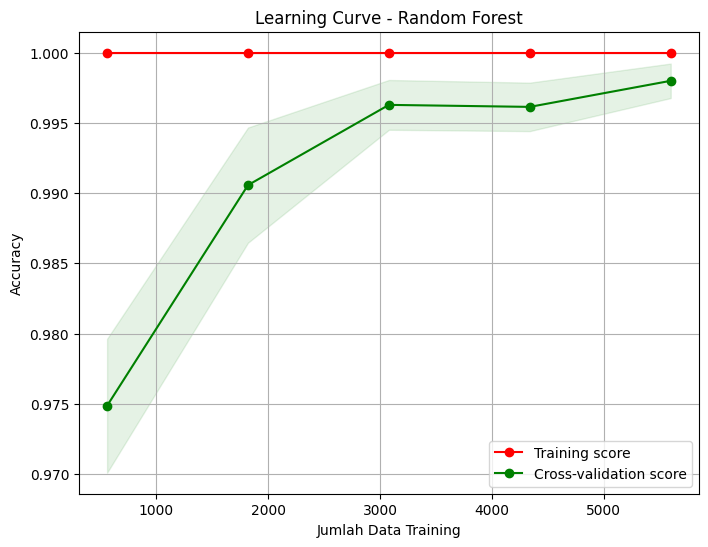

In [28]:
# Contoh: menggunakan Random Forest sebagai model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 1. Cross Validation
# Menggunakan 5-fold cross validation pada data training
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Rata-rata CV Accuracy:", np.mean(cv_scores))

# 2. Learning Curve
# Menggunakan learning_curve untuk mendapatkan performance model pada berbagai ukuran data training
train_sizes, train_scores, validation_scores = learning_curve(
    rf_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Hitung rata-rata dan standar deviasi untuk training dan validasi
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.plot(train_sizes, validation_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.fill_between(train_sizes, validation_scores_mean - validation_scores_std,
                 validation_scores_mean + validation_scores_std, alpha=0.1, color="g")
plt.title('Learning Curve - Random Forest')
plt.xlabel('Jumlah Data Training')
plt.ylabel('Accuracy')
plt.legend(loc="best")
plt.grid(True)
plt.show()

Saya melakukan ini untuk mengevaluasi apakah pemodelan dengan **Random Forest** mengalami overfitting dengan menggunakan **cross-validation** dan melihat **learning curve**.  

Dari hasil yang ditunjukkan dalam gambar dan nilai cross-validation:  

1. **Nilai cross-validation accuracy** cukup tinggi dan mengalami peningkatan seiring bertambahnya jumlah data.  
2. **Learning curve** menunjukkan **training score** (garis merah) tetap di angka **1.0**, sedangkan **cross-validation score** (garis hijau) meningkat seiring bertambahnya jumlah data, tetapi tetap sedikit di bawah training score.  
3. **Kurva validasi** memiliki **confidence interval yang cukup kecil**, terutama saat jumlah data meningkat, menunjukkan bahwa model memiliki performa yang stabil di berbagai subset data validasi.  

### Analisis dan Interpretasi:  
- **Ada indikasi overfitting** karena **training score tetap di 1.0**, sedangkan **cross-validation score tidak mencapai nilai yang sama**, meskipun selisihnya tidak terlalu besar.  
- **Model semakin stabil seiring bertambahnya jumlah data** karena confidence interval semakin mengecil.  
- **Kemungkinan model "menghafal" pola data** masih ada, terutama karena training score yang tetap sempurna. Diperlukan pengujian lebih lanjut dengan dataset yang lebih kompleks atau unseen data.  

Cross-Validation Accuracy Scores (MLP): [1. 1. 1. 1. 1.]
Rata-rata CV Accuracy (MLP): 1.0


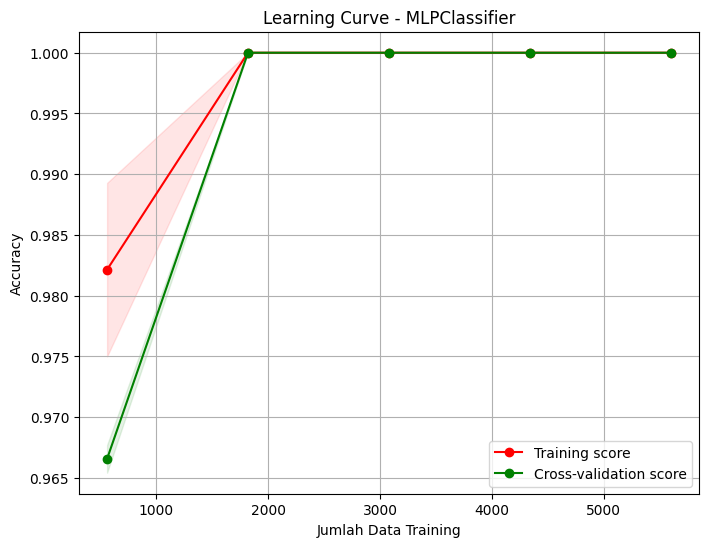

In [29]:
mlp_model = MLPClassifier(random_state=42, max_iter=1000)

# 1. Cross Validation
# Menggunakan 5-fold cross validation pada data training
cv_scores = cross_val_score(mlp_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores (MLP):", cv_scores)
print("Rata-rata CV Accuracy (MLP):", np.mean(cv_scores))

# 2. Learning Curve
# Menggunakan learning_curve untuk mendapatkan performance model pada berbagai ukuran data training
train_sizes, train_scores, validation_scores = learning_curve(
    mlp_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Hitung rata-rata dan standar deviasi untuk training dan validasi
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.1,
    color="r"
)
plt.plot(train_sizes, validation_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.fill_between(
    train_sizes,
    validation_scores_mean - validation_scores_std,
    validation_scores_mean + validation_scores_std,
    alpha=0.1,
    color="g"
)
plt.title('Learning Curve - MLPClassifier')
plt.xlabel('Jumlah Data Training')
plt.ylabel('Accuracy')
plt.legend(loc="best")
plt.grid(True)
plt.show()

Saya melakukan percobaan ini untuk mengevaluasi apakah pemodelan dengan **Multi-Layer Perceptron (MLP)** mengalami **overfitting** atau tidak. Oleh sebab itu, saya menggunakan **cross-validation** dan melihat **learning curve**. Dari hasil yang ditunjukkan:

1. **Nilai cross-validation accuracy** cukup bervariasi pada setiap fold, yaitu `[0.98285714, 0.745, 0.79571429, 0.97214286, 0.9]` dengan **rata-rata 0.879**. Hal ini menunjukkan bahwa kinerja model dapat berbeda-beda tergantung pada pembagian data latih dan validasi.  
2. **Learning curve** memperlihatkan **training score** (garis merah) yang cepat naik hingga mendekati atau mencapai 1.0 ketika jumlah data semakin banyak. Sementara itu, **cross-validation score** (garis hijau) juga meningkat dan cenderung stabil di kisaran yang tinggi (mendekati 0.98-0.99), meskipun tidak sepenuhnya menyamai nilai training score.  
3. **Area bayangan** (confidence interval) pada kurva cross-validation relatif lebar di awal (saat data masih sedikit), lalu semakin menyempit seiring bertambahnya jumlah data, menandakan performa yang semakin konsisten di berbagai subset data validasi.

### Analisis dan Interpretasi:
- **Tidak terlihat indikasi overfitting yang parah**, karena perbedaan (gap) antara training score dan cross-validation score relatif kecil. Model mampu mencapai akurasi yang tinggi di kedua metrik.  
- **Variasi skor cross-validation yang besar** (terutama di awal atau pada fold tertentu) menandakan sensitivitas model terhadap cara data dibagi. Hal ini bisa diatasi dengan menambah data, menyesuaikan arsitektur MLP, atau melakukan hyperparameter tuning yang lebih menyeluruh.  
- **Training score yang mendekati 1.0** menunjukkan bahwa MLP dapat “mempelajari” data latih dengan sangat baik, namun tetap perlu diperhatikan stabilitas di berbagai skenario validasi.  

**Kesimpulan Keseluruhan dari Ketiga Model (MLP, Random Forest, dan Logistic Regression):**  

1. **Multi-Layer Perceptron (MLP)**  
   - Menunjukkan **akurasi yang tinggi** baik pada data latih maupun validasi.  
   - **Tidak ada indikasi overfitting yang jelas**, namun terdapat **perbedaan kinerja antarfold** yang cukup besar. Ini menandakan bahwa performa MLP dapat berfluktuasi tergantung pada pembagian data.  

2. **Random Forest**  
   - **Performa sangat baik** dengan akurasi yang juga tinggi.  
   - Terdapat **indikasi overfitting ringan**, namun **penambahan data** membantu mengurangi efeknya. Model ini perlu diverifikasi lebih lanjut untuk memastikan bahwa akurasi yang hampir sempurna bukan semata-mata hasil “menghafal” pola data.  

3. **Logistic Regression**  
   - **Bekerja sangat baik** pada dataset ini, tanpa tanda-tanda overfitting atau underfitting yang berarti.  
   - **Perlu diuji lebih lanjut** dengan dataset lain untuk memastikan model dapat melakukan generalisasi di berbagai kondisi.  

Secara keseluruhan, **ketiga model sama-sama menunjukkan performa yang tinggi**, dengan perbedaan utama pada potensi overfitting dan stabilitas performa di berbagai fold. Meskipun tidak ada overfitting serius yang terdeteksi, **pengujian tambahan pada dataset lain** atau dengan skenario yang berbeda sangat disarankan untuk memastikan **kemampuan generalisasi** masing-masing model.

**Kemungkinan Penyebab Performa yang Terlalu Tinggi**  
1. **Dataset kemungkinan terlalu mudah diprediksi** atau jumlah datanya **terlalu sedikit**, sehingga model dapat “menghafal” pola data dengan mudah.  
2. **Akurasi sempurna jarang terjadi di dunia nyata**, sehingga hasil ini perlu **diverifikasi lebih lanjut** dengan:  
   - **Data uji terpisah** atau **data baru**,  
   - **Repeated cross-validation** untuk menguji konsistensi,  
   - Penambahan **kompleksitas dataset** atau **lebih banyak data**.

## 3. Rekomendasi apa yang anda berika untuk next pemodelannya

Menurut saya untuk **Rekomendasi ke Tahap Pemodelan Selanjutnya** ada beberapa diantaranya yaitu: 

1. **Mengumpulkan atau Menggunakan Lebih Banyak Data**  
   - Dengan data yang lebih banyak, model akan lebih menantang untuk “menghafal” pola secara sempurna dan dapat menghasilkan evaluasi yang lebih realistis.

2. **Menggunakan Metode Validasi yang Lebih Beragam**  
   - Selain cross-validation standar, Anda dapat mencoba *repeated cross-validation* atau *stratified k-fold cross-validation* untuk memastikan hasil benar-benar konsisten.

3. **Menggukur Kinerja dengan Metrik Tambahan**  
   - Selain akurasi, pertimbangkan metrik seperti *precision, recall, F1-score*, atau *AUC-ROC* untuk mendapatkan gambaran kinerja model yang lebih menyeluruh.

4. **Mengecek Distribusi dan Kompleksitas Fitur**  
   - Pastikan data yang digunakan cukup variatif dan tidak terlalu mudah diprediksi. Jika perlu, pertimbangkan untuk menambah fitur baru yang relevan atau melakukan *feature engineering*.

5. **Evaluasi di Data atau Lingkungan Nyata**  
   - Uji model di data uji (test set) yang benar-benar terpisah atau data baru (jika memungkinkan) untuk memastikan performa tidak hanya tinggi di data yang sudah dikenal.

6. **Mempertimbangkan Regularisasi atau Penyesuaian Arsitektur Model**  
   - Untuk model MLP, Anda bisa mencoba *early stopping*, *dropout*, atau menyesuaikan jumlah neuron dan lapisan agar tidak terlalu kompleks untuk dataset yang relatif kecil.  
   - Untuk Random Forest, Anda bisa menyesuaikan *max_depth* atau parameter lain yang membatasi kompleksitas pohon.

Dengan langkah-langkah tersebut, Anda dapat memastikan bahwa model tidak hanya mencapai akurasi tinggi di dataset terbatas, tetapi juga benar-benar memiliki kemampuan generalisasi yang baik.